<a href="https://colab.research.google.com/github/nklsrmy/japanese_web_design_density_analysis/blob/main/04_clustering_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Japanese Website Design Density Analysis
**Objective**

This study analyzes structural features of Japanese and Western websites to understand how high information density may affect user experience (UX), and to examine how Japanese developers adapt to modern web design trends.

The analysis uses measurable homepage characteristics and applies clustering techniques to identify structural design patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("website_features_processed - master_dataset.csv")
df.head()

,row_id,website_name,website_link,domain,country,link_density,visual_assets,info_load_chars,scroll_depth,font_variety
0,JP001,Amazon Japan,https://www.amazon.co.jp,ecommerce,Japan,363,236,4159,9,2
1,JP002,Yahoo Shopping Japan,https://shopping.yahoo.co.jp,ecommerce,Japan,93,71,1744,4,1
2,JP003,Mercari,https://www.mercari.com/jp,ecommerce,Japan,38,19,373,3,1
3,JP004,Uniqlo Japan,https://www.uniqlo.com/jp,ecommerce,Japan,339,333,1193,1,6
4,JP005,Muji Japan,https://www.muji.com/jp,ecommerce,Japan,326,196,3166,22,2


In [3]:
# dataset overview
df.shape

(74, 10)

In [4]:
df.describe()

,link_density,visual_assets,info_load_chars,scroll_depth,font_variety
count,74.000000,74.000000,74.000000,74.000000,74.000000
mean,312.918919,92.040541,4439.972973,14.297297,4.486486
std,234.461012,86.156347,3411.575424,10.470742,2.858504
min,1.000000,6.000000,149.000000,1.000000,1.000000
25%,163.000000,31.750000,1770.500000,8.000000,3.000000
50%,273.000000,66.000000,3459.000000,11.000000,4.000000
75%,383.250000,116.000000,6112.750000,17.750000,5.000000
max,1378.000000,336.000000,14201.000000,51.000000,22.000000


In [5]:
# check for missing value
df.isnull().sum()

,0
row_id,0
website_name,0
website_link,0
domain,0
country,0
link_density,0
visual_assets,0
info_load_chars,0
scroll_depth,0
font_variety,0


##Dataset and Variables

**The dataset consists of 74 websites:**

49 Japanese websites and 25 Western websites

The following variables are used as structural indicators of information density:

- link_density — number of hyperlinks (navigation complexity)
- visual_assets — number of images (visual load)
- info_load_chars — total visible text (reading load)
- scroll_depth — page length in folds (content depth)
- font_variety — number of font families (visual consistency)

These variables are treated as proxies for UX complexity and interface density.

##Outlier Inspection

In [26]:
df.sort_values("scroll_depth", ascending=False).head()

,row_id,website_name,website_link,domain,country,link_density,visual_assets,info_load_chars,scroll_depth,font_variety,cluster
25,JP026,Nagoya University,https://www.nagoya-u.ac.jp,education,Japan,268,82,7573,51,4,0
57,WS009,Bloomberg,https://www.bloomberg.com,news,USA,469,147,14201,48,7,2
53,WS005,IKEA,https://www.ikea.com,ecommerce,Sweden,181,50,7167,44,1,0
12,JP013,Yomiuri Shimbun,https://www.yomiuri.co.jp,news,Japan,1378,336,10221,41,4,2
55,WS007,CNN,https://www.cnn.com,news,USA,484,70,7100,29,5,0


In [27]:
df.sort_values("font_variety", ascending=False).head()

,row_id,website_name,website_link,domain,country,link_density,visual_assets,info_load_chars,scroll_depth,font_variety,cluster
39,JP040,Sony Japan,https://www.sony.co.jp,technology,Japan,112,37,3507,18,22,0
73,WS025,Sony US,https://www.sony.com,technology,USA,303,38,5590,5,10,0
62,WS014,Stanford University,https://www.stanford.edu,education,USA,118,34,7294,25,10,0
56,WS008,Reuters,https://www.reuters.com,news,UK,344,7,11170,28,8,0
71,WS023,Verizon,https://www.verizon.com,technology,USA,378,36,2576,10,8,0


##Feature Selection

In [11]:
features = df[[
    "link_density",
    "visual_assets",
    "info_load_chars",
    "scroll_depth",
    "font_variety"
]]

##Standardization

In [12]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [29]:
##scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
##scaled_df.head()

##Elbow Method

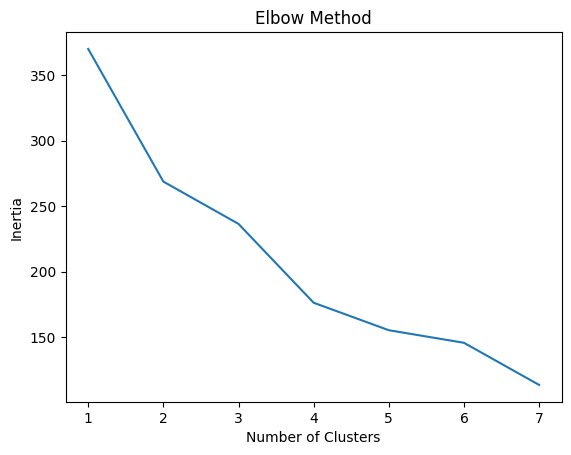

In [30]:
# elbow method
inertia = []

for k in range(1, 8):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_features)
    inertia.append(model.inertia_)

plt.figure()
plt.plot(range(1, 8), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

##K-Means Clustering

In [31]:
# k-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(scaled_features)

##Cluster Size

In [32]:
df["cluster"].value_counts()

,count
cluster,
0,48
1,20
2,6


##Cluster Summary

In [33]:
cluster_summary = df.groupby("cluster")[[
    "link_density",
    "visual_assets",
    "info_load_chars",
    "scroll_depth",
    "font_variety"
]].mean()

cluster_summary

,link_density,visual_assets,info_load_chars,scroll_depth,font_variety
cluster,,,,,
0,199.00,45.8125,4018.354167,13.958333,4.8125
1,457.45,154.4000,3168.150000,11.250000,3.5500
2,742.50,254.0000,12052.333333,27.166667,5.0000


##**Cluster Interpretation**

Three structural design patterns emerge:

- **Cluster 0** — **Moderate Density**
> Balanced structure with moderate links, visuals, and text. Suggests more readable and stable layouts.

- **Cluster 1** — **Visual-Interactive Density**
> High links and visuals with lower text load. Indicates modern, interaction-focused design patterns.

- **Cluster 2** — **High Information Density**
> Very high values across all features. Represents traditional dense homepage structures, which may increase cognitive load for users.

##Adaptation Analysis

In [18]:
japan_df = df[df["country"] == "Japan"]

japan_df[["website_name", "cluster"]].sort_values("cluster")

,website_name,cluster
1,Yahoo Shopping Japan,0
2,Mercari,0
7,Nitori,0
8,Kakaku,0
15,Yahoo News Japan,0
26,Hokkaido University,0
27,Kyushu University,0
29,Japan Post,0
24,Tohoku University,0
25,Nagoya University,0


In [19]:
japan_cluster_counts = japan_df["cluster"].value_counts()
japan_cluster_counts

,count
cluster,
0,28
1,17
2,4


##**Adaptation of Japanese Websites to Modern Design Trends**

Japanese websites are distributed across all three clusters.

Some Japanese websites fall into Cluster 1, which reflects modern design characteristics such as reduced text density and stronger visual hierarchy. This indicates adoption of global web design trends.

However, a portion of websites remains in Cluster 2, representing traditional high-density layouts.

This distribution suggests that Japanese developers are gradually adapting to modern design practices, while still maintaining elements of traditional dense design.

Overall, Japanese web design demonstrates a hybrid evolution rather than a complete transition.

##Cluster vs Country

In [20]:
df.groupby(["cluster", "country"]).size()

cluster  country
0        Japan      28
         Sweden      1
         UK          6
         USA        13
1        Japan      17
         USA         3
2        Japan       4
         UK          1
         USA         1
dtype: int64

##PCA

In [21]:
# pca visualization
pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled_features)

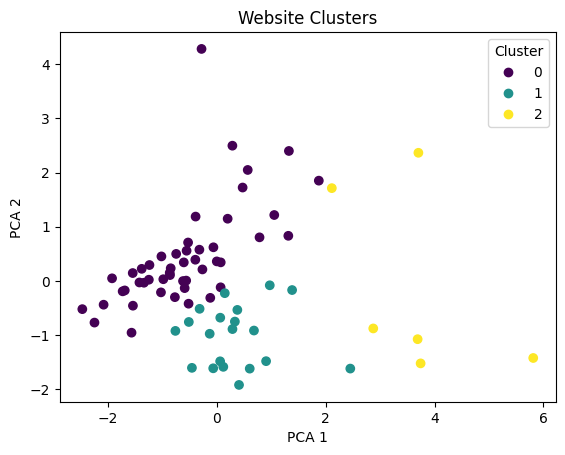

In [22]:
plt.figure()

scatter = plt.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=df["cluster"]
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Website Clusters")

plt.legend(*scatter.legend_elements(), title="Cluster")

plt.savefig("cluster_pca_plot.png")

plt.show()

##Country Comparison

In [23]:
# country comparison
country_summary = df.groupby("country")[[
    "link_density",
    "visual_assets",
    "info_load_chars",
    "scroll_depth",
    "font_variety"
]].mean()

country_summary

,link_density,visual_assets,info_load_chars,scroll_depth,font_variety
country,,,,,
Japan,339.061224,107.346939,3763.102041,13.387755,4.122449
Sweden,181.000000,50.000000,7167.000000,44.000000,1.000000
UK,220.571429,48.714286,7927.285714,16.857143,5.000000
USA,283.352941,68.235294,4794.588235,14.117647,5.529412


**Country Comparison Interpretation**

Japanese websites show higher average link density and visual asset usage than several Western groups, suggesting stronger homepage navigation complexity and denser visual presentation.

Although text volume is not always the highest, Japanese websites frequently combine multiple structural density indicators simultaneously, which may increase scanning demands for site visitors.

This supports the interpretation that Japanese homepage density is often driven by navigation and interface complexity rather than text volume alone.

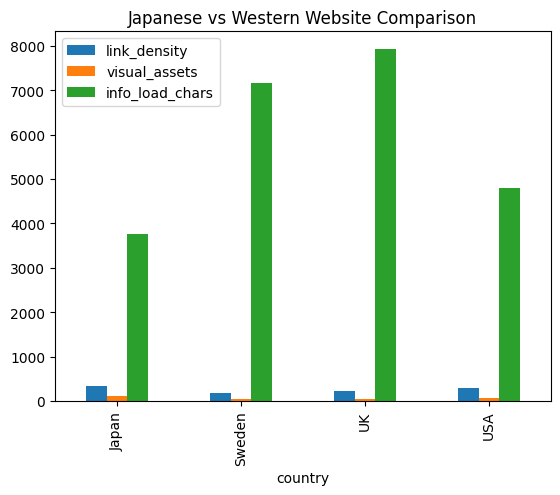

In [24]:
# country bar chart
country_summary[[
    "link_density",
    "visual_assets",
    "info_load_chars"
]].plot(kind="bar")

plt.title("Japanese vs Western Website Comparison")
plt.show()

##**UX Implications of Information Density**

- Japanese websites tend to have higher link density and visual elements, contributing to more complex navigation structures.

- This increased density may raise cognitive load and require more effort for users to scan and process information.

- Thus, homepage structure plays a key role in shaping user experience beyond text content alone.

##**Conclusion**

- The analysis shows that Japanese website design is not uniform but instead consists of multiple structural patterns ranging from traditional high-density layouts to more modern, visually structured designs.

- While high information density remains present, there is clear evidence that some Japanese websites are adapting to global web design trends.

- This suggests an ongoing transition in design practices, where modern approaches are gradually integrated into traditionally dense layouts.

In [34]:
df.to_csv("website_clustered_results.csv", index=False)